In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Automobile_data.csv")


In [4]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.4,23.0,106,4800,26,27,22470


In [5]:
df = df.replace("?", np.nan)

In [6]:
numeric_columns = [
    "horsepower",
    "engine-size",
    "city-mpg",
    "price",
    "curb-weight",
    "width",
    "length",
    "wheel-base",
    "bore",
    "stroke",
    "compression-ratio",
    "peak-rpm",
    "highway-mpg",
    "height",
    "symboling",
    "normalized-losses"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

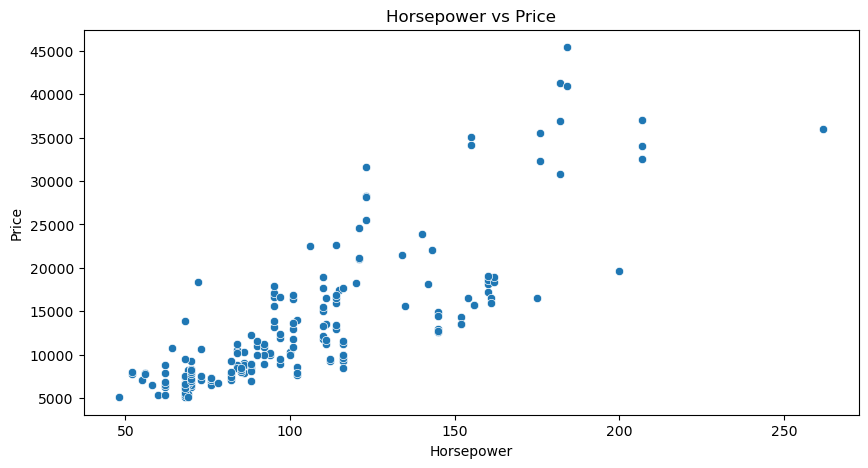

In [15]:
# ============================================
# 2. Horsepower vs Price
# ============================================

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x="horsepower",
    y="price"
)

plt.title("Horsepower vs Price")
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.show()

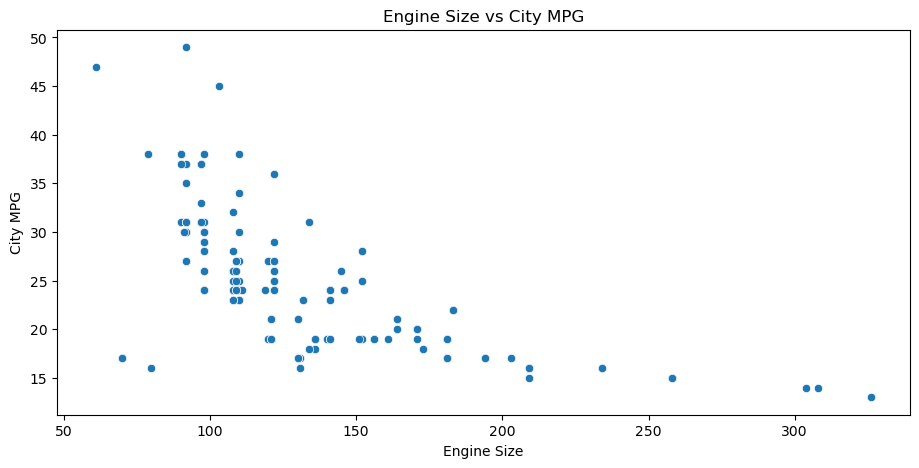

In [16]:
# 3. Engine Size vs City MPG
# ============================================

plt.figure(figsize=(11, 5))

sns.scatterplot(
    data=df,
    x="engine-size",
    y="city-mpg"
)

plt.title("Engine Size vs City MPG")
plt.xlabel("Engine Size")
plt.ylabel("City MPG")
plt.show()

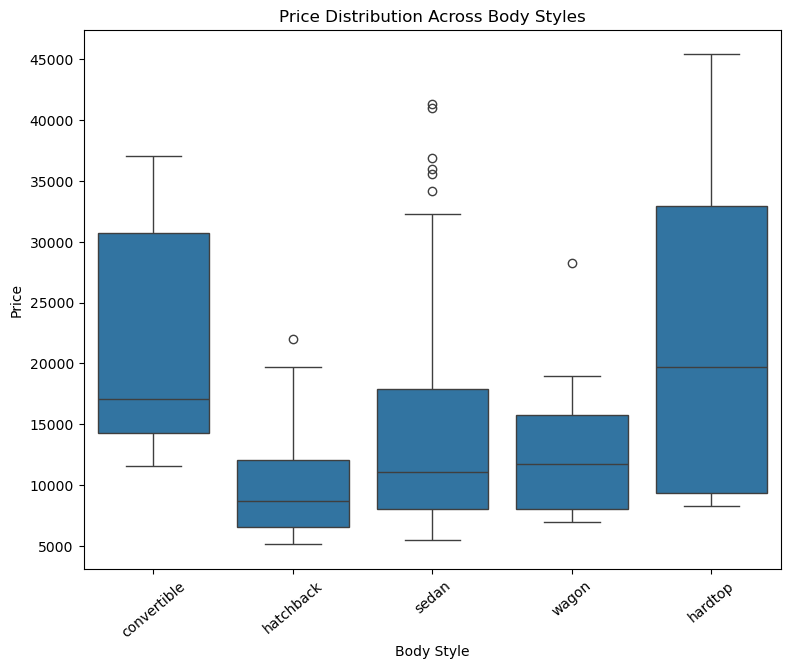

In [22]:
# 4. Price Distribution by Body Style
# ============================================

plt.figure(figsize=(9, 7))

sns.boxplot(
    data=df,
    x="body-style",
    y="price"
)

plt.title("Price Distribution Across Body Styles")
plt.xlabel("Body Style")
plt.ylabel("Price")
plt.xticks(rotation=40)
plt.show()



In [10]:
# 5. Select Technical Specifications
# ============================================

technical_specs = [
    "symboling",
    "wheel-base",
    "length",
    "width",
    "height",
    "curb-weight",
    "engine-size",
    "bore",
    "stroke",
    "compression-ratio",
    "horsepower",
    "peak-rpm",
    "city-mpg",
    "highway-mpg",
    "price"
]

technical_df = df[technical_specs]

In [11]:
technical_df

,symboling,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,109.1,188.8,68.9,55.5,2952,141,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0
201,-1,109.1,188.8,68.8,55.5,3049,141,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0
202,-1,109.1,188.8,68.9,55.5,3012,173,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
203,-1,109.1,188.8,68.9,55.5,3217,145,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0


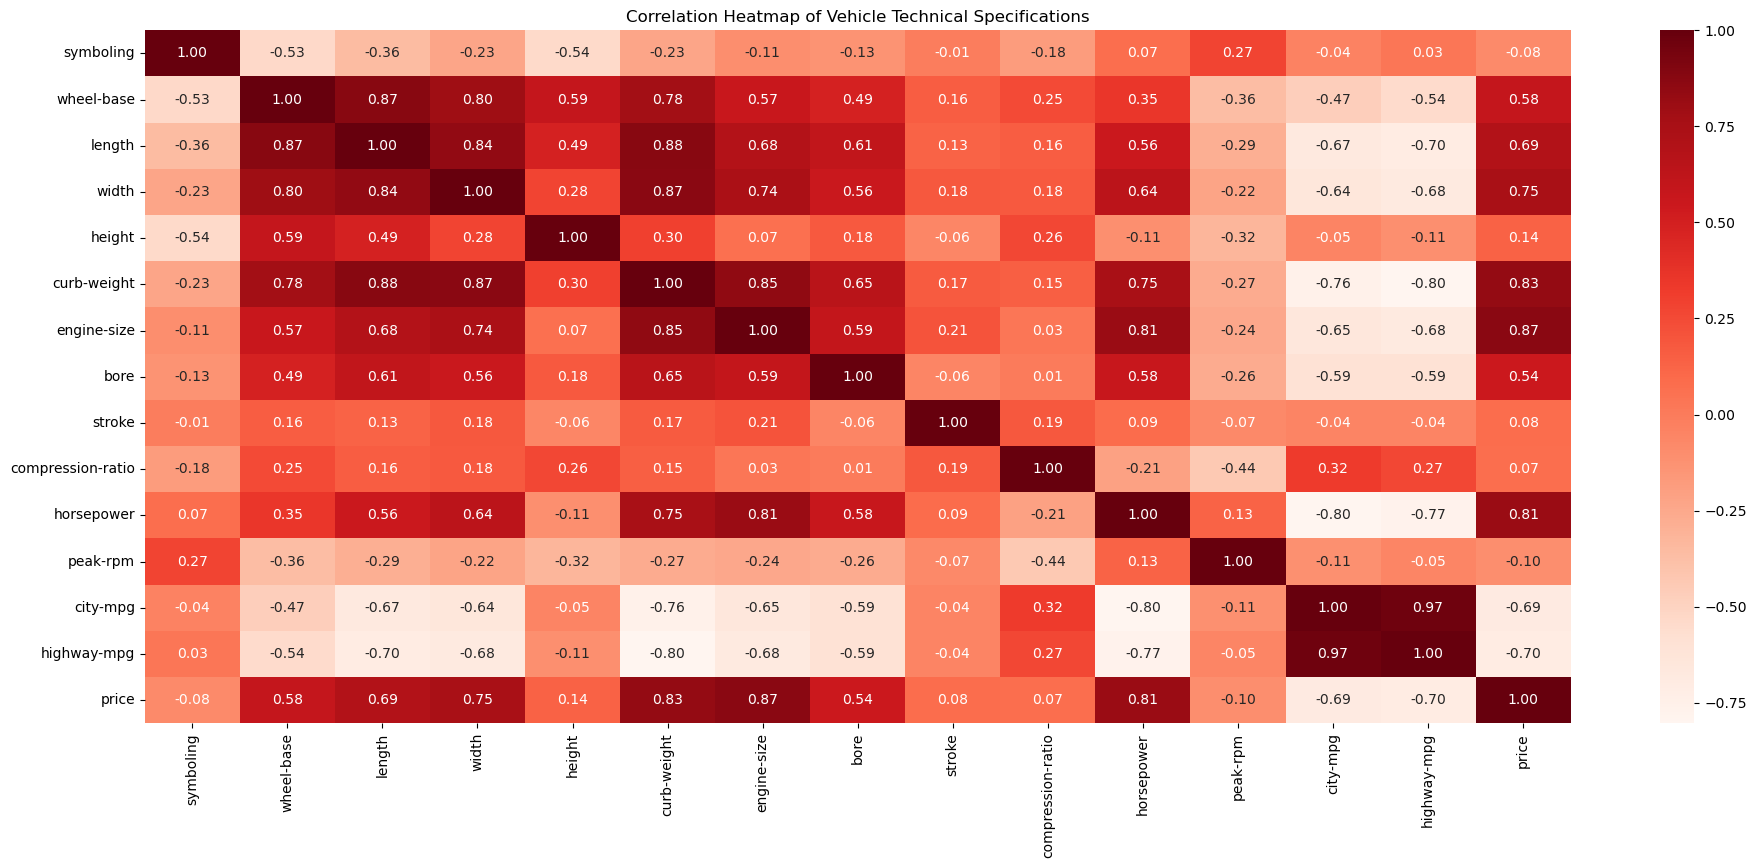

In [25]:
# 6. Correlation Matrix
# ============================================

correlation = technical_df.corr()


# ============================================
# 7. Correlation Heatmap
# ============================================

plt.figure(figsize=(23, 9))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Reds",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Vehicle Technical Specifications")
plt.show()

In [13]:
# 8. Correlation with Price
# ============================================

price_correlation = correlation["price"].sort_values(
    ascending=False
)

print("Correlation with Vehicle Price:")
print(price_correlation)

Correlation with Vehicle Price:
price                1.000000
engine-size          0.872335
curb-weight          0.834415
horsepower           0.810533
width                0.751265
length               0.690628
wheel-base           0.584642
bore                 0.543436
height               0.135486
stroke               0.082310
compression-ratio    0.071107
symboling           -0.082391
peak-rpm            -0.101649
city-mpg            -0.686571
highway-mpg         -0.704692
Name: price, dtype: float64


In [14]:
# 9. Basic Market Analysis
# ============================================

print("\nAverage Price by Body Style:")
print(
    df.groupby("body-style")["price"]
      .mean()
      .sort_values(ascending=False)
)

print("\nAverage Horsepower by Body Style:")
print(
    df.groupby("body-style")["horsepower"]
      .mean()
      .sort_values(ascending=False)
)

print("\nAverage City MPG by Body Style:")
print(
    df.groupby("body-style")["city-mpg"]
      .mean()
      .sort_values(ascending=False)
)


Average Price by Body Style:
body-style
hardtop        22208.500000
convertible    21890.500000
sedan          14459.755319
wagon          12371.960000
hatchback       9957.441176
Name: price, dtype: float64

Average Horsepower by Body Style:
body-style
hardtop        142.250000
convertible    131.666667
sedan          103.104167
hatchback      101.333333
wagon           97.750000
Name: horsepower, dtype: float64

Average City MPG by Body Style:
body-style
hatchback      26.314286
sedan          25.322917
wagon          24.040000
hardtop        21.625000
convertible    20.500000
Name: city-mpg, dtype: float64
